In [4]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

conn = psycopg2.connect(
    host="localhost", port=5432,
    database="it_sla",
    user="postgres", password="postgres123"
)

df = pd.read_sql("SELECT * FROM tickets", conn)
print(df.shape)
print(df.columns.tolist())
df.head()

(9980, 15)
['ticket_id', 'created_date', 'resolved_date', 'category', 'sub_category', 'priority', 'status', 'subject', 'description', 'resolution', 'product_service', 'department', 'satisfaction_rating', 'time_to_resolution_hours', 'text_length']


/tmp/ipykernel_39275/1201289837.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM tickets", conn)


,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours,text_length
0,TKT-10001,2025-05-09,2025-05-09 02:12:00,Access/Permissions,Account Lockout,Critical,Resolved,Account locked after password change,"hi there, changed my password yesterday and no...",Account lockout was caused by mobile devices t...,Azure AD,Logistics,4.0,2.2,296
1,TKT-10002,2023-09-13,2023-09-13 07:48:00,Security,Malware,Critical,Closed,USB drive triggered security alert,plugged in a usb drive i got at a conference a...,USB contained autorun malware that was caught ...,Palo Alto Cortex,Customer Support,3.0,7.8,245
2,TKT-10003,2025-01-28,2025-01-28 03:12:00,Hardware,Desktop,Critical,Closed,Need more RAM — computer too slow with current...,my macbook pro m3 only has 8gb ram and i regul...,Approved RAM upgrade request. Installed additi...,MacBook Pro M3,Product,3.0,3.2,323
3,TKT-10005,2025-01-11,2025-01-12 19:06:00,Hardware,Desktop,Low,Closed,Need more RAM — computer too slow with current...,my dell precision 5570 only has 8gb ram and i ...,Approved RAM upgrade request. Installed additi...,Dell Precision 5570,Customer Support,3.0,43.1,280
4,TKT-10006,2023-08-23,2023-08-23 05:36:00,Software,Installation,Critical,Resolved,Can't install Salesforce — access denied,trying to install salesforce on my workstation...,Verified software approval in request system. ...,Salesforce,Sales,2.0,5.6,234


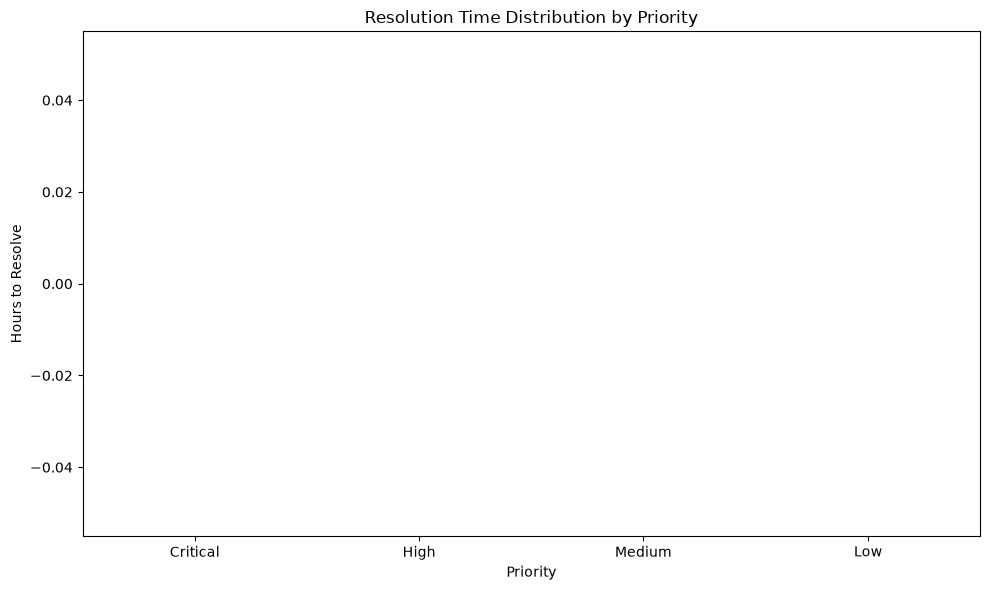

In [6]:
priority_order = ["Critical", "High", "Medium", "Low"]
df_plot = df[df["priority"].isin(priority_order)]

fig, ax = plt.subplots(figsize=(10, 6))
data_by_priority = [
    df_plot[df_plot["priority"] == p]["time_to_resolution_hours"].values
    for p in priority_order
]
ax.boxplot(data_by_priority)
ax.set_xticklabels(priority_order)
ax.set_title("Resolution Time Distribution by Priority")
ax.set_xlabel("Priority")
ax.set_ylabel("Hours to Resolve")
plt.tight_layout()
plt.show()

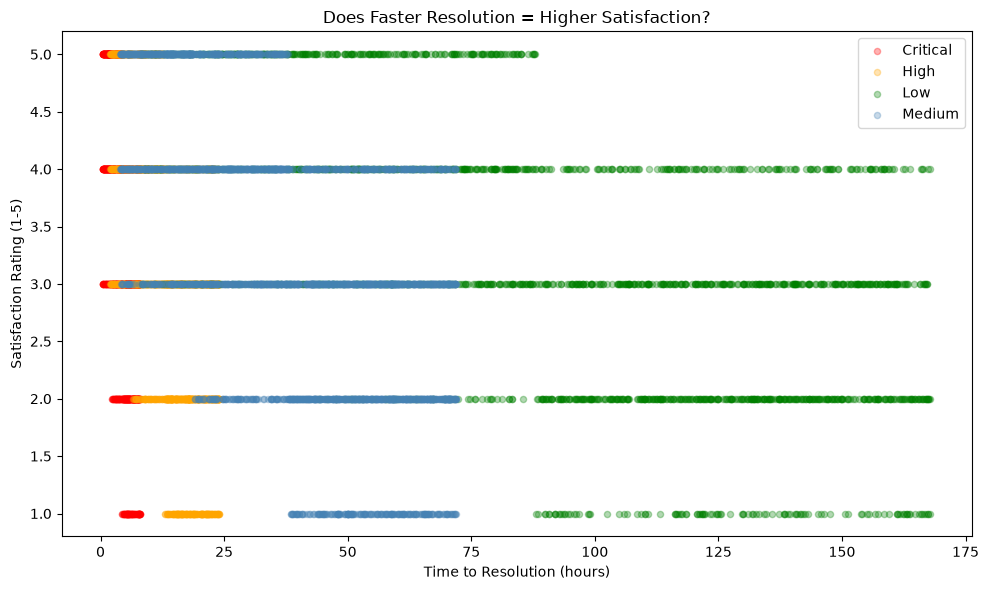

In [7]:
plt.figure(figsize=(10, 6))
colors = {"Critical": "red", "High": "orange", "Medium": "steelblue", "Low": "green"}
for priority, group in df.groupby("priority"):
    plt.scatter(
        group["time_to_resolution_hours"],
        group["satisfaction_rating"],
        alpha=0.3, color=colors.get(priority, "grey"),
        label=priority, s=20
    )
plt.xlabel("Time to Resolution (hours)")
plt.ylabel("Satisfaction Rating (1-5)")
plt.title("Does Faster Resolution = Higher Satisfaction?")
plt.legend()
plt.tight_layout()
plt.show()

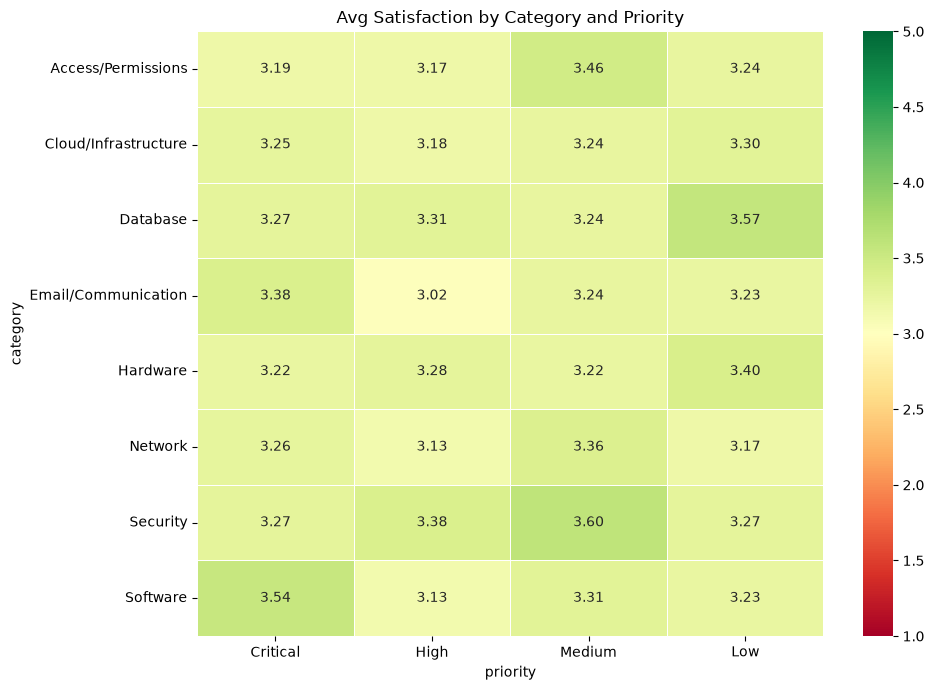

In [8]:
pivot = df.pivot_table(
    values="satisfaction_rating",
    index="category",
    columns="priority",
    aggfunc="mean"
)
pivot = pivot[["Critical", "High", "Medium", "Low"]]

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".2f",
            cmap="RdYlGn", vmin=1, vmax=5, linewidths=0.5)
plt.title("Avg Satisfaction by Category and Priority")
plt.tight_layout()
plt.show()

In [9]:
import os
os.makedirs("/workspaces/it_sla_analysis/exports", exist_ok=True)

df.to_csv("/workspaces/it_sla_analysis/exports/tickets_full.csv", index=False)

cat_summary = df.groupby(["category", "priority"]).agg(
    ticket_count=("ticket_id", "count"),
    avg_resolution_hrs=("time_to_resolution_hours", "mean"),
    avg_satisfaction=("satisfaction_rating", "mean")
).reset_index().round(2)
cat_summary.to_csv("/workspaces/it_sla_analysis/exports/category_summary.csv", index=False)

dept_summary = df.groupby("department").agg(
    tickets=("ticket_id", "count"),
    avg_hrs=("time_to_resolution_hours", "mean"),
    avg_sat=("satisfaction_rating", "mean")
).reset_index().round(2)
dept_summary.to_csv("/workspaces/it_sla_analysis/exports/dept_summary_py.csv", index=False)

print("Exports complete")
print(f"tickets_full: {len(df)} rows")
print(f"category_summary: {len(cat_summary)} rows")
print(f"dept_summary: {len(dept_summary)} rows")

Exports complete
tickets_full: 9980 rows
category_summary: 32 rows
dept_summary: 14 rows
